# 1장 실습 — 왜 통째로 배우는가

**대응 이론** 1장 「VLA와 피지컬 AI의 좌표계」 · **실행 등급 A** (CPU / Colab 무료 티어, 전체 약 4분)

로봇 소프트웨어를 만드는 전통적인 방법은 **나누는 것**이다. 카메라에서 물체를 찾고(지각), 어디로 갈지 정하고(계획), 관절을 움직인다(제어). 각 단계는 따로 만들고 따로 검증한다. 이 방식은 수십 년 동안 작동했고, 지금도 많은 산업용 시스템이 이렇게 돌아간다.

VLA 는 이 분해를 **하나의 신경망으로 대체하겠다**는 주장이다. 그 주장이 왜 나왔는지를 이 노트북에서 세 가지로 잰다. 그리고 마지막에 **그 주장이 언제 틀리는지**도 잰다.

1. 단계마다의 오차는 곱해진다
2. 인터페이스가 나르지 못하는 것
3. 그런데 데이터가 적으면 나누는 쪽이 이긴다

In [1]:
%matplotlib inline
import os, time
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
import koreanize_matplotlib

torch.manual_seed(0); np.random.seed(0)
torch.set_num_threads(os.cpu_count() or 2)

RED, GREY, PINK = "#e32c24", "#c8c8c8", "#f6c9c6"
print("torch", torch.__version__)

torch 2.9.1


## 1. 단계마다의 오차는 곱해진다

파이프라인의 각 단계는 자기 몫의 오차를 갖는다. 지각이 물체 위치를 조금 틀리게 잡고, 계획이 경로를 조금 틀리게 내고, 제어가 조금 어긋나게 움직인다.

각 단계가 **아주 정확해도** 문제가 되는 이유는 오차가 더해지는 것이 아니라 **쌓이기 때문**이다. 허용 오차 8cm 안에 들어야 성공하는 과제에서, 단계마다 표준편차 얼마씩을 얹으면 성공률이 어떻게 되는지 본다.

허용 오차 0.08 안에 들어야 성공

  단계별 오차 σ            지각 후      계획 후      제어 후
  ----------------------------------------------
  σ=0.02              100%       98%       93%
  σ=0.03               97%       84%       70%
  σ=0.04               86%       63%       49%
  σ=0.06               59%       36%       26%


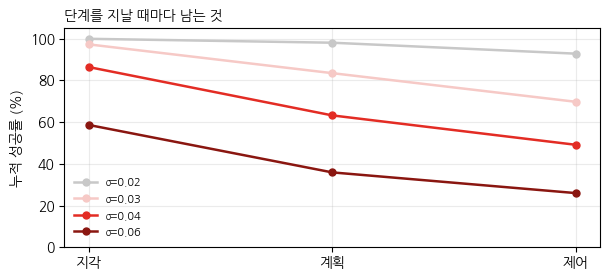

In [2]:
TOL = 0.08                                  # 성공 판정 허용 오차
rng = np.random.default_rng(3)
N = 20000
truth = np.zeros((N, 2), np.float32)

print(f"허용 오차 {TOL} 안에 들어야 성공")
print(f"\n  {'단계별 오차 σ':<14}{'지각 후':>10}{'계획 후':>10}{'제어 후':>10}")
print("  " + "-" * 46)
curves = {}
for sig in (0.02, 0.03, 0.04, 0.06):
    p = truth.copy(); row = []
    for k in range(3):
        p = p + rng.normal(0, sig, p.shape).astype(np.float32)
        row.append((np.linalg.norm(p - truth, axis=1) < TOL).mean() * 100)
    curves[sig] = row
    print(f"  σ={sig:<12.2f}{row[0]:>9.0f}%{row[1]:>9.0f}%{row[2]:>9.0f}%")

fig, ax = plt.subplots(figsize=(6.2, 2.9))
for (sig, row), c in zip(curves.items(), [GREY, PINK, RED, "#8a1610"]):
    ax.plot([1, 2, 3], row, "o-", color=c, lw=1.8, ms=5, label=f"σ={sig}")
ax.set_xticks([1, 2, 3]); ax.set_xticklabels(["지각", "계획", "제어"])
ax.set_ylabel("누적 성공률 (%)"); ax.set_ylim(0, 105)
ax.legend(fontsize=8, frameon=False); ax.grid(alpha=.25)
ax.set_title("단계를 지날 때마다 남는 것", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

## 2. 인터페이스가 나르지 못하는 것

두 번째 논거는 더 근본적이다. 모듈 사이의 **인터페이스가 무엇을 나를 수 있는지**가 시스템의 능력을 정한다.

장면에 빨간 블록과 파란 블록이 있고 지시는 「빨간 블록으로 가라」다. 지각 모듈이 좌표를 내고 그 다음 단계가 그것을 쓴다. 그런데 **지각 모듈이 지시문을 보지 못하면** 어떻게 되는가.

In [3]:
def scene(n, seed):
    r = np.random.default_rng(seed)
    pr = r.uniform(-.8, .8, (n, 2)).astype(np.float32)      # 빨간 블록
    pb = r.uniform(-.8, .8, (n, 2)).astype(np.float32)      # 파란 블록
    who = (r.random(n) < .5).astype(np.int64)               # 0=빨강, 1=파랑
    tgt = np.where(who[:, None] == 0, pr, pb).astype(np.float32)
    obs = np.concatenate([pr, pb, np.eye(2, dtype=np.float32)[who]], 1)
    return obs, tgt, who

class MLP(nn.Module):
    def __init__(s, i, o, h=128):
        super().__init__()
        s.f = nn.Sequential(nn.Linear(i, h), nn.GELU(), nn.Linear(h, h), nn.GELU(), nn.Linear(h, o))
    def forward(s, x): return s.f(x)

def fit(m, X, Y, steps=2000, lr=2e-3, seed=0):
    torch.manual_seed(seed)
    opt = torch.optim.AdamW(m.parameters(), lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.OneCycleLR(opt, lr, steps, pct_start=.15)
    g = torch.Generator().manual_seed(1)
    for i in range(steps):
        idx = torch.randint(0, len(X), (256,), generator=g)
        loss = F.smooth_l1_loss(m(X[idx]), Y[idx], beta=.02)
        opt.zero_grad(); loss.backward(); opt.step(); sch.step()
    return m

Otr, Ttr, _ = scene(8000, 0); Ote, Tte, Wte = scene(3000, 7)

a = fit(MLP(6, 2), torch.tensor(Otr), torch.tensor(Ttr))              # 지시를 본다
with torch.no_grad(): ea = np.linalg.norm(a(torch.tensor(Ote)).numpy() - Tte, axis=1)
b = fit(MLP(4, 2), torch.tensor(Otr[:, :4]), torch.tensor(Ttr))       # 지시를 못 본다
with torch.no_grad():
    pb_ = b(torch.tensor(Ote[:, :4])).numpy()
eb = np.linalg.norm(pb_ - Tte, axis=1)

print(f"  {'지각 단계가':<24}{'성공률':>8}{'평균 오차':>11}")
print("  " + "-" * 44)
print(f"  {'지시문을 본다':<24}{(ea<TOL).mean():>8.0%}{ea.mean():>11.4f}")
print(f"  {'지시문을 못 본다':<24}{(eb<TOL).mean():>8.0%}{eb.mean():>11.4f}")

mid = (Ote[:, :2] + Ote[:, 2:4]) / 2
print(f"\n  지시를 못 본 모델의 출력이 두 블록 중점에서 떨어진 거리: {np.linalg.norm(pb_-mid,axis=1).mean():.4f}")
print(f"  (참고) 두 블록 사이 거리의 절반 평균: {np.linalg.norm(Ote[:,:2]-Ote[:,2:4],axis=1).mean()/2:.4f}")

  지각 단계가                       성공률      평균 오차
  --------------------------------------------
  지시문을 본다                     100%     0.0025
  지시문을 못 본다                    13%     0.4203

  지시를 못 본 모델의 출력이 두 블록 중점에서 떨어진 거리: 0.2261
  (참고) 두 블록 사이 거리의 절반 평균: 0.4200


## 3. 그런데 데이터가 적으면 나누는 쪽이 이긴다

여기까지만 보면 종단간이 항상 옳아 보인다. 그렇지 않다. 나누는 것에는 큰 이점이 하나 있다 — **중간 단계에 라벨을 줄 수 있다.**

지각 모듈을 따로 학습시키면 「이 이미지에 블록이 여기 있다」는 라벨로 직접 감독할 수 있다. 종단간 학습은 최종 행동만 보고 그 모든 것을 스스로 알아내야 한다.

이번에는 진짜 이미지를 쓴다. 24×24 픽셀에 블록 두 개가 놓이고, 같은 망에 **중간 라벨(두 블록의 좌표)에 대한 보조 손실**을 걸었을 때와 걸지 않았을 때를 시연 수를 바꿔 가며 비교한다.

  시연 수              중간 라벨 있음        종단간 (최종만)
  ---------------------------------------------
  100                    14%               7%
  300                    99%              72%
  1000                  100%             100%
  4000                  100%             100%
  (160s)


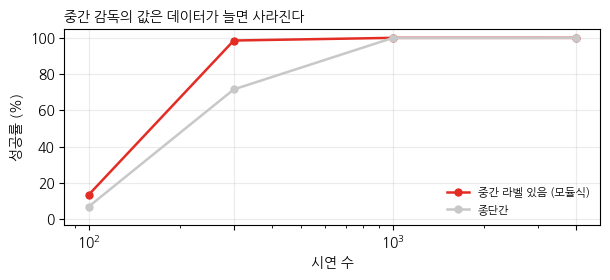

  300                    99%              71%


  1000                  100%             100%


  4000                  100%             100%
  (90s)


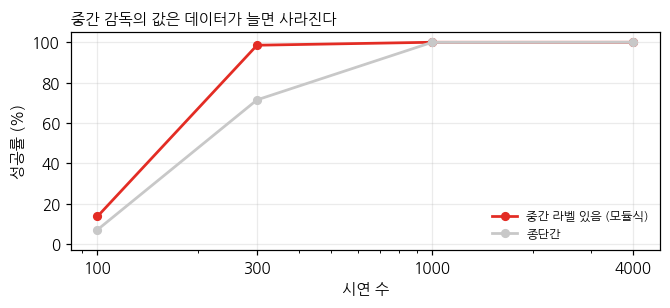

In [5]:
IMG, SQ = 24, 5
def img_scene(n, seed):
    r = np.random.default_rng(seed)
    im = np.full((n, 3, IMG, IMG), .92, np.float32); cen = np.zeros((n, 2, 2), np.float32)
    for i in range(n):
        pos = []
        for k, c in enumerate([(1, .15, .15), (.2, .35, 1)]):
            for _ in range(60):
                x, y = r.integers(1, IMG - SQ - 1, 2)
                if all(abs(x - a) > SQ + 1 or abs(y - b) > SQ + 1 for a, b in pos): break
            pos.append((x, y)); cen[i, k] = [(x + SQ/2)/IMG*2 - 1, (y + SQ/2)/IMG*2 - 1]
            for ch in range(3): im[i, ch, y:y+SQ, x:x+SQ] = c[ch]
    who = (r.random(n) < .5).astype(np.int64)
    return (torch.tensor(im), torch.tensor(np.eye(2, dtype=np.float32)[who]),
            torch.tensor(cen[np.arange(n), who]), torch.tensor(cen))

class Policy(nn.Module):
    def __init__(s, d=64):
        super().__init__()
        s.e = nn.Sequential(
            nn.Conv2d(3, 16, 3, 2, 1), 
            nn.GELU(), 
            nn.Conv2d(16, 32, 3, 2, 1), 
            nn.GELU(),
            nn.Flatten(), 
            nn.Linear(32*6*6, d), 
            nn.GELU()
        )
        s.aux = nn.Linear(d, 4)                                   # 중간 라벨: 두 블록 좌표
        s.head = nn.Sequential(nn.Linear(d + 2, 64), nn.GELU(), nn.Linear(64, 2))
    def forward(s, im, lang):
        z = s.e(im); return s.head(torch.cat([z, lang], 1)), s.aux(z)

def fit_pol(m, D, steps, aux_w, lr=2e-3, seed=0):
    im, lang, tgt, cen = D; torch.manual_seed(seed)
    opt = torch.optim.AdamW(m.parameters(), lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.OneCycleLR(opt, lr, steps, pct_start=.15)
    g = torch.Generator().manual_seed(1)
    for i in range(steps):
        idx = torch.randint(0, len(im), (min(128, len(im)),), generator=g)
        a, z = m(im[idx], lang[idx])
        loss = F.smooth_l1_loss(a, tgt[idx], beta=.02)
        if aux_w: loss = loss + aux_w * F.smooth_l1_loss(z, cen[idx].reshape(len(idx), 4), beta=.02)
        opt.zero_grad(); loss.backward(); opt.step(); sch.step()
    return m

t0 = time.time()
TOL2 = 0.12
Dte = img_scene(1500, 99)
ns, with_aux, without = [100, 300, 1000, 4000], [], []
print(f"  {'시연 수':<10}{'중간 라벨 있음':>16}{'종단간 (최종만)':>17}")
print("  " + "-" * 45)
for n in ns:
    D = img_scene(n, 11); res = []
    for w in (1.0, 0.0):
        m = fit_pol(Policy(), D, 1500, w)
        with torch.no_grad(): a, _ = m(Dte[0], Dte[1])
        res.append((torch.norm(a - Dte[2], dim=1).numpy() < TOL2).mean() * 100)
    with_aux.append(res[0]); without.append(res[1])
    print(f"  {n:<10}{res[0]:>15.0f}%{res[1]:>16.0f}%")
print(f"  ({time.time()-t0:.0f}s)")

fig, ax = plt.subplots(figsize=(6.2, 2.9))
ax.plot(ns, with_aux, "o-", color=RED, lw=1.8, ms=5, label="중간 라벨 있음 (모듈식)")
ax.plot(ns, without, "o-", color=GREY, lw=1.8, ms=5, label="종단간")
ax.set_xscale("log"); ax.set_xticks(ns)
ax.set_xlabel("시연 수"); ax.set_ylabel("성공률 (%)"); ax.set_ylim(-3, 105)
ax.legend(fontsize=8, frameon=False); ax.grid(alpha=.25)
ax.set_title("중간 감독의 값은 데이터가 늘면 사라진다", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

### 다음 장으로
다음 장에서는 그 하나의 망이 무엇을 출력해야 하는지를 본다. 「액션」이라고 뭉뚱그려 부른 것이 실제로는 여러 선택의 묶음이고, 그 선택이 학습 난이도를 수십 배 바꾼다.